# VaR & Expected Shortfall: a backtested multi-method risk engine

**Demonstration notebook.** It reproduces the main results of the project from top to bottom, calling the `riskengine` package. No business logic lives here.

**The question.** A bank wants to know how much a portfolio can lose in one day, with 99% confidence. Three standard methods answer it: historical simulation, a Gaussian parametric formula, and a Gaussian Monte Carlo simulation. Which one can be trusted?

**The approach.** Each method forecasts the Value at Risk (VaR) and the Expected Shortfall (ES) of the next day using only the previous 500 days. These 4,530 out-of-sample forecasts are then compared with what really happened, and tested statistically (Kupiec, Christoffersen, Basel traffic light). The Monte Carlo core is also written in C++.

**Conventions.** The P&L is signed (a loss is negative). VaR and ES are positive numbers expressing a loss. A *violation* is a day where the loss exceeds the VaR.

> To run this notebook you need `results/backtest.csv` and `results/stat_tests.csv` (produced by `scripts/run_backtest.py` and `scripts/run_stat_tests.py`) and the benchmark files in `results/`.

In [1]:
# Setup. The notebook lives in notebooks/, but the project paths (data/, results/,
# figures/) are relative to the project root, so we move up one folder if needed.
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image
from scipy import stats

from riskengine.backtest import count_violations, violation_summary
from riskengine.measures import historical_var_es, monte_carlo_var_es, parametric_var_es
from riskengine.plotting import plot_covid_zoom, plot_pnl_vs_var, plot_violation_rates
from riskengine.portfolio import (
    DEFAULT_WEIGHTS, V0, compute_log_returns, load_prices, portfolio_pnl)
from riskengine.tests_stat import kupiec_pof

plt.rcParams["figure.dpi"] = 80        # lighter figures inside the notebook
pd.options.display.float_format = "{:,.2f}".format

## 2. Data

Five US-listed ETFs cover four asset classes: US equities (SPY), emerging-market equities (EEM), US Treasuries 7-10 years (IEF), gold (GLD) and the EUR/USD currency (FXE). Prices are daily adjusted closes (dividends and splits corrected) from 2006, when the youngest ETF was listed, to the end of 2025.

In [2]:
prices = load_prices()
print(f"{len(prices):,} trading days, from {prices.index[0].date()} to {prices.index[-1].date()}")
prices.tail(3)

5,031 trading days, from 2006-01-03 to 2025-12-31


,EEM,FXE,GLD,IEF,SPY
Date,,,,,
2025-12-29,54.38,108.02,398.60,94.06,682.52
2025-12-30,54.60,107.77,398.89,93.96,681.69
2025-12-31,54.43,107.83,396.31,93.65,676.64


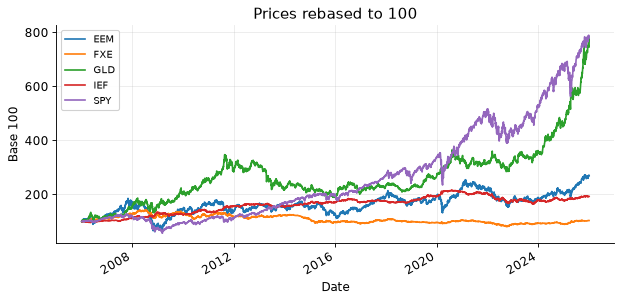

In [3]:
(prices / prices.iloc[0] * 100).plot(figsize=(9, 4), title="Prices rebased to 100")
plt.ylabel("Base 100")
plt.show()

## 3. The portfolio

An equally weighted portfolio (20% in each asset), worth 1,000,000 and rebalanced every day, so its daily P&L is `V0 * sum(w_i * r_i)` with daily log-returns `r_i`. The weights are deliberately simple: the goal is to measure risk, not to optimise the allocation.

In [4]:
returns = compute_log_returns(prices)[list(DEFAULT_WEIGHTS)]
pnl = portfolio_pnl(returns)
print(f"{len(pnl):,} daily returns")
pd.Series(DEFAULT_WEIGHTS, name="weight").to_frame().T

5,030 daily returns


,SPY,EEM,IEF,GLD,FXE
weight,0.20,0.20,0.20,0.20,0.20


In [5]:
summary = pd.Series({
    "annualised volatility (%)": 100 * pnl.std() / V0 * np.sqrt(252),
    "skewness": stats.skew(pnl),
    "excess kurtosis": stats.kurtosis(pnl),
    "worst day": pnl.min(),
    "best day": pnl.max(),
})
summary.to_frame("daily P&L")

,daily P&L
annualised volatility (%),10.86
skewness,-0.01
excess kurtosis,10.69
worst day,"-53,845.24"
best day,"66,799.89"


The excess kurtosis is far above 0 (a Gaussian has exactly 0): extreme days are much more frequent than a normal law allows. The histogram below uses a **logarithmic vertical axis** so the tails are visible: the red Gaussian curve with the same mean and standard deviation falls far below the observed tails.

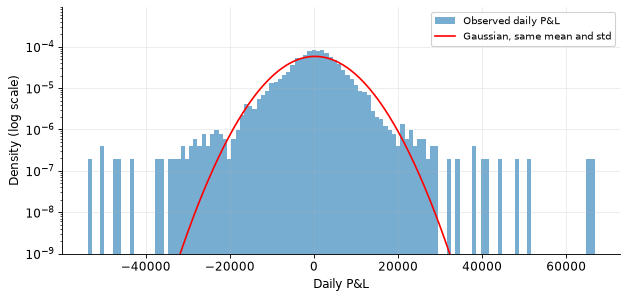

In [6]:
x = np.linspace(pnl.min(), pnl.max(), 400)
plt.figure(figsize=(9, 4))
plt.hist(pnl, bins=120, density=True, alpha=0.6, label="Observed daily P&L")
plt.plot(x, stats.norm.pdf(x, pnl.mean(), pnl.std()), "r", label="Gaussian, same mean and std")
plt.yscale("log")
plt.ylim(bottom=1e-9)
plt.xlabel("Daily P&L")
plt.ylabel("Density (log scale)")
plt.legend()
plt.show()

## 4. The three methods on one date

We forecast the risk of **12 March 2020**, in the middle of the COVID crash. Each method sees only the 500 days *before* that date (`iloc[i - 500:i]` stops at day `i - 1`, which prevents look-ahead bias).

- **Historical**: empirical quantile and tail mean of the past P&L.
- **Parametric**: closed-form Gaussian VaR and ES from the estimated mean and covariance.
- **Monte Carlo**: 50,000 simulated scenarios of correlated Gaussian returns (Cholesky decomposition).

In [7]:
date = pd.Timestamp("2020-03-12")
i = returns.index.get_loc(date)
window, win_pnl = returns.iloc[i - 500:i], pnl.iloc[i - 500:i]
w = np.array(list(DEFAULT_WEIGHTS.values()))

levels = (0.95, 0.975, 0.99)
methods = {
    "historical": lambda a: historical_var_es(win_pnl, a),
    "parametric": lambda a: parametric_var_es(window, w, a),
    "monte carlo": lambda a: monte_carlo_var_es(window, w, a, n_sims=50_000),
}
rows = {(name, f"{a:.1%}"): f(a) for name, f in methods.items() for a in levels}
table = pd.DataFrame(rows, index=["VaR", "ES"]).T
print(f"Realised P&L on {date.date()}: {pnl.iloc[i]:,.0f}")
table.style.format("{:,.0f}")

Realised P&L on 2020-03-12: -50,793


Three things to notice. First, at every level the ES is larger than the VaR: the ES is the *average* loss beyond the VaR, so it measures how bad the bad days are, not only where they start. Second, parametric and Monte Carlo agree (they use the same Gaussian model; the small gap is simulation noise). Third, the realised loss of that day is several times larger than every 99% VaR: no method saw the crash coming, because all three look at the past only.

## 5. Validating the Monte Carlo

Monte Carlo and parametric VaR use the same model, so Monte Carlo must converge to the closed-form value. The simulation error should shrink like `1/sqrt(N)`: ten times more scenarios, a 3.2 times smaller error. For each number of scenarios, we average the relative error over 10 random seeds.

In [8]:
sizes = [1_000, 10_000, 100_000, 1_000_000]
var_exact, _ = parametric_var_es(window, w, 0.99)
errors = {n: [abs(monte_carlo_var_es(window, w, 0.99, n_sims=n, seed=s)[0] / var_exact - 1)
              for s in range(10)] for n in sizes}
mean_error = np.array([100 * np.mean(errors[n]) for n in sizes])
pd.DataFrame({"mean relative error (%)": mean_error}, index=pd.Index(sizes, name="scenarios"))

,mean relative error (%)
scenarios,
1000,5.78
10000,1.64
100000,0.59
1000000,0.14


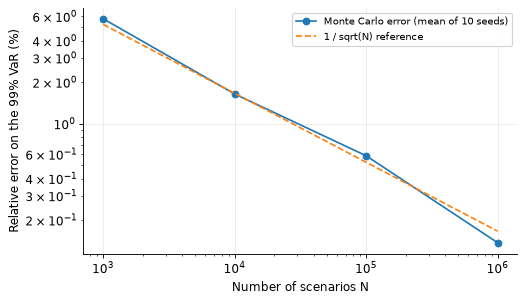

In [9]:
fit = np.exp(np.mean(np.log(mean_error * np.sqrt(sizes))))      # best constant c in c / sqrt(N)
plt.figure(figsize=(7, 4))
plt.loglog(sizes, mean_error, "o-", label="Monte Carlo error (mean of 10 seeds)")
plt.loglog(sizes, fit / np.sqrt(sizes), "--", label="1 / sqrt(N) reference")
plt.xlabel("Number of scenarios N")
plt.ylabel("Relative error on the 99% VaR (%)")
plt.legend()
plt.show()

## 6. Backtesting

The full rolling-window backtest takes a few minutes, so it is run once by `scripts/run_backtest.py` and saved in `results/backtest.csv`. Each row is a day with the realised P&L and the VaR and ES forecast by each method *using only the 500 previous days*.

In [10]:
results = pd.read_csv("results/backtest.csv", index_col=0, parse_dates=True)
print(f"{len(results):,} out-of-sample forecasts per method, "
      f"{results.index[0].date()} to {results.index[-1].date()}")
counts = violation_summary(results).reset_index()
counts["alpha"] = counts["alpha"].map("{:.1%}".format)
counts

4,530 out-of-sample forecasts per method, 2007-12-31 to 2025-12-31


,method,alpha,forecasts,violations,observed %,expected %
0,hist,95.0%,4530,228,5.03,5.00
1,hist,97.5%,4530,120,2.65,2.50
2,hist,99.0%,4530,55,1.21,1.00
3,param,95.0%,4530,220,4.86,5.00
4,param,97.5%,4530,137,3.02,2.50
5,param,99.0%,4530,87,1.92,1.00
6,mc,95.0%,4530,217,4.79,5.00
7,mc,97.5%,4530,137,3.02,2.50
8,mc,99.0%,4530,86,1.90,1.00


If a method is well calibrated, the observed violation rate matches `1 - confidence level`. At 95% all three methods are close. At 99% the two Gaussian methods are violated nearly twice as often as expected, while historical simulation is closer to the target.

### Figure 1: P&L and 99% VaR

Each red dot is a day where the loss exceeded the historical VaR. They concentrate in a few episodes (2008, 2020). The historical VaR is a staircase: it jumps when an extreme day enters or leaves the 500-day window.

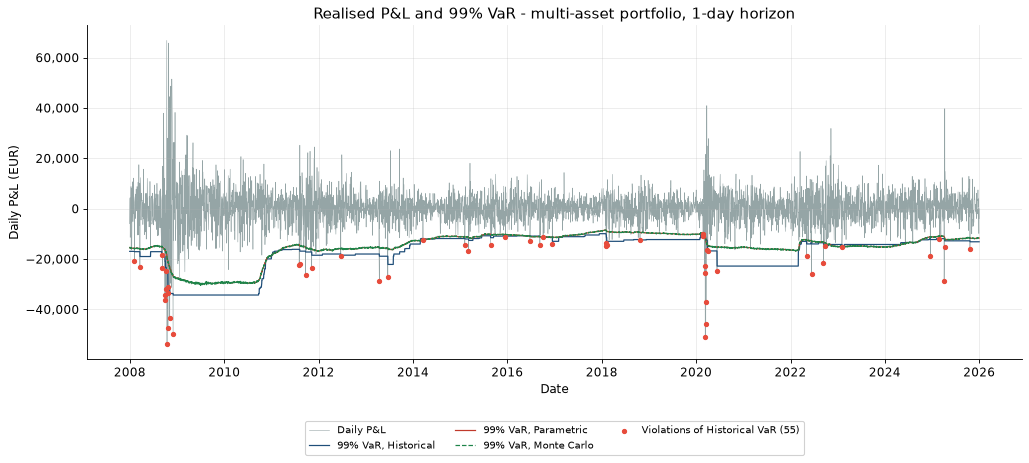

In [11]:
fig = plot_pnl_vs_var(results)

### Zoom on March 2020

The VaR forecasts are drawn against the daily P&L during the crash. All three methods lag behind the market: the volatility regime changed faster than 500 days of history can reveal.

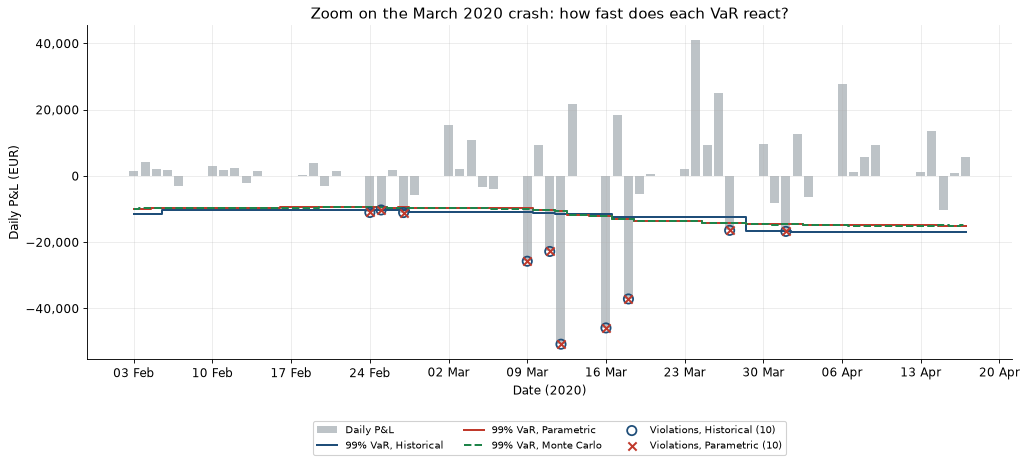

In [12]:
fig = plot_covid_zoom(results)

### Violation rates

The rate of violations by method, level and year, against the expected rate.

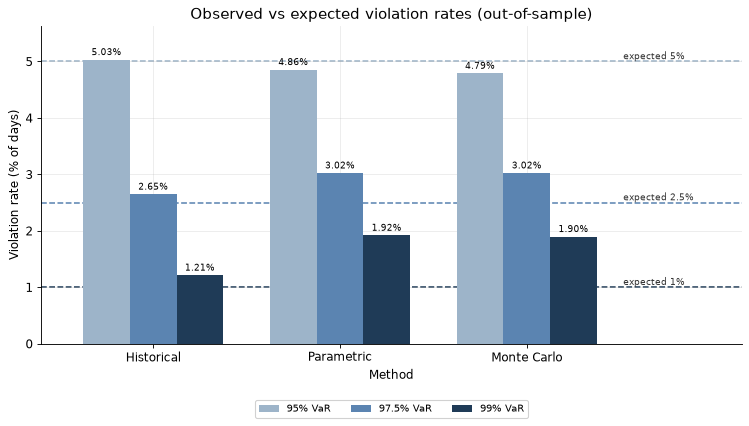

In [13]:
fig = plot_violation_rates(results)

## 7. Statistical tests

Counting violations is not enough: a count of 55 for 45.3 expected may or may not be a statistical anomaly. Two tests formalise the question.

- **Kupiec (proportion of failures)** tests the *frequency*: is the violation rate compatible with `1 - confidence level`?
- **Christoffersen (independence)** tests the *clustering*: does a violation today make a violation tomorrow more likely? A good model should not.

A small p-value (below 0.05) means the model is rejected. A large p-value is only the absence of evidence against it, not a proof that it is right.

In [14]:
tests = pd.read_csv("results/stat_tests.csv", index_col=["method", "alpha"])
shown = tests[["violations", "expected", "p_kupiec", "p_indep", "p_cc"]]
shown.style.format({"expected": "{:.1f}", "p_kupiec": "{:.1e}", "p_indep": "{:.1e}", "p_cc": "{:.1e}"})

`p_kupiec` is the frequency test, `p_indep` the independence test and `p_cc` the joint conditional-coverage test. A single test can also be called directly; for example, the historical method at 99%:

In [15]:
v = count_violations(results, "hist", 990).to_numpy()
lr, p_value, n_violations, expected = kupiec_pof(v, 0.99)
print(f"Historical, 99%: {n_violations} violations for {expected:.1f} expected, Kupiec p-value = {p_value:.3f}")

Historical, 99%: 55 violations for 45.3 expected, Kupiec p-value = 0.161


**Reading the table.**

- **Frequency.** At 99%, the two Gaussian methods are clearly rejected (p below 1e-7). Historical simulation is not rejected (p = 0.16), but with 55 violations for 45 expected the test has limited power.
- **Independence.** Every method is rejected at every level: violations come in clusters, because the three models assume a constant volatility. After a violation, the probability of another one the next day is several times higher than after a calm day (see `pi11` against `pi01` in `results/stat_tests.csv`).
- **The Gaussian assumption costs little near the centre and a lot in the tail**, which is exactly where VaR is used.

### Basel traffic light (99% VaR, 250-day windows)

The Basel framework classifies a model from its number of violations over the last 250 days: green (up to 4), yellow (5 to 9), red (10 or more). The table gives the zone of the last window and the share of all rolling windows in each zone.

In [16]:
basel = tests.xs(0.99, level="alpha")[["last250_viol", "last250_zone", "share_yellow", "share_red", "worst250"]]
basel.style.format({"last250_viol": "{:.0f}", "worst250": "{:.0f}",
                    "share_yellow": "{:.1%}", "share_red": "{:.1%}"})

,last250_viol,last250_zone,share_yellow,share_red,worst250
method,,,,,
hist,4,green,4.1%,9.6%,14
param,4,green,16.8%,16.3%,23
mc,4,green,16.4%,16.3%,23


The last window is green for every method, but over the whole history the Gaussian models spend a large share of the windows in the yellow and red zones, mostly around 2008 and 2020.

## 8. C++ performance

The Monte Carlo scenario generator exists in two interchangeable versions: NumPy (`backend="python"`) and a compiled C++ module exposed with pybind11 (`backend="cpp"`). They share the same model but use different random number generators, so they cannot give identical numbers; they are validated statistically (20 seeds, agreement within 1%, convergence to the analytical value).

The benchmark was run on a laptop whose speed drifts by about 2x between runs, so only **ratios between implementations timed back to back** are reported (`scripts/benchmark_cpp.py`).

In [17]:
bench = pd.read_csv("results/benchmark.csv")
bench[["n_sims", "speedup_vs_numpy", "speedup_vs_folded", "function_speedup", "noise_cpp"]]

,n_sims,speedup_vs_numpy,speedup_vs_folded,function_speedup,noise_cpp
0,1000,2.42,1.75,1.17,1.17
1,10000,1.64,1.28,1.26,1.19
2,50000,1.77,1.24,1.75,1.42
3,100000,3.08,1.31,1.92,2.79
4,500000,1.94,1.36,1.87,1.13
5,1000000,2.09,1.44,1.89,1.05


Full backtest (1,262 forecasts): C++ is 1.47x faster


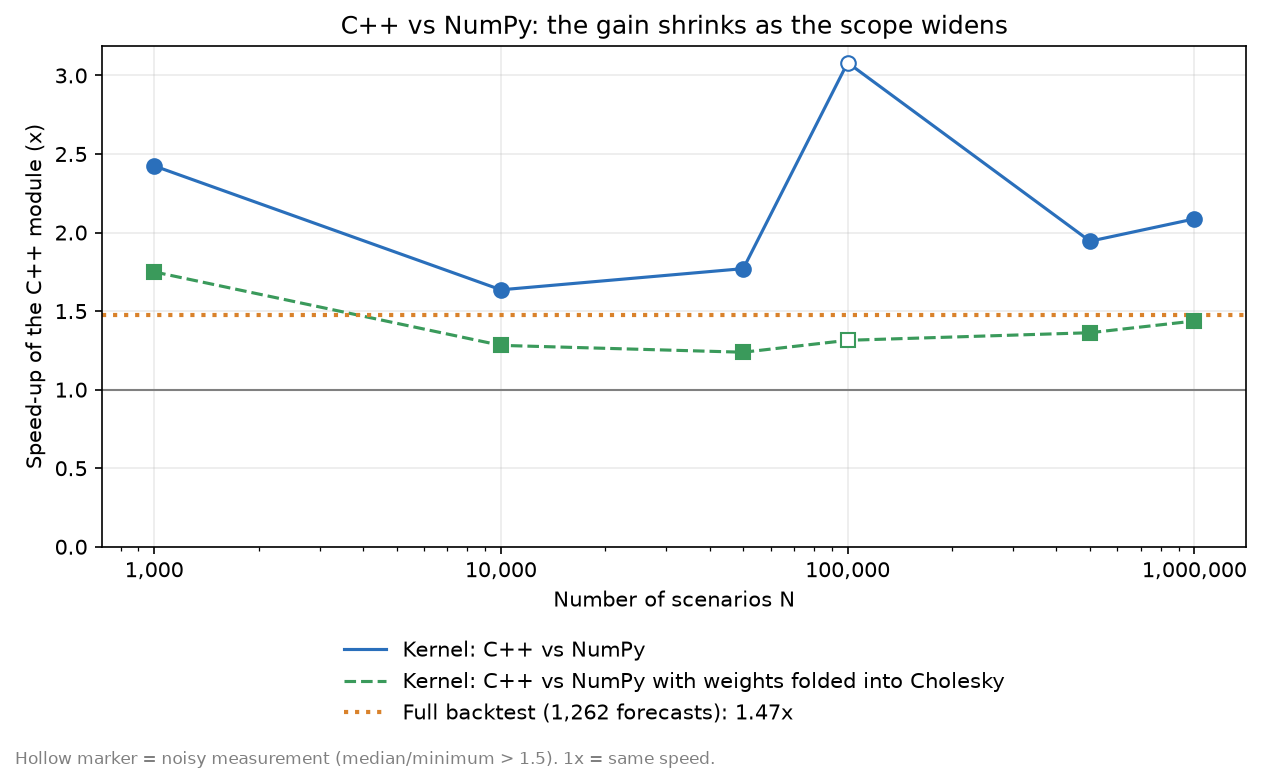

In [18]:
pipe = pd.read_csv("results/benchmark_pipeline.csv").set_index("backend")
print(f"Full backtest ({int(pipe.loc['cpp', 'forecasts']):,} forecasts): "
      f"C++ is {pipe.loc['python', 'total_s'] / pipe.loc['cpp', 'total_s']:.2f}x faster")
Image("figures/fig5_benchmark.png", width=700)

The gain shrinks as the scope widens: about 2x for scenario generation, about 1.9x for the whole `monte_carlo_var_es` call, about 1.5x for the full backtest. Only the simulation is accelerated; pandas estimation, quantiles and the other two methods are unchanged.

If the C++ module is compiled on your machine, the next cell compares both backends on the 12 March 2020 window.

In [19]:
try:
    from riskengine import mc_engine  # noqa: F401
    both = {b: monte_carlo_var_es(window, w, 0.99, n_sims=1_000_000, backend=b)[0]
            for b in ("python", "cpp")}
    both["analytical (parametric)"] = var_exact
    print(pd.Series(both, name="99% VaR").map("{:,.0f}".format).to_string())
except ImportError:
    print("The C++ module is not compiled on this machine: see the README to build it.")

python                     10,508
cpp                        10,549
analytical (parametric)    10,528


## Conclusion and limits

- The Gaussian assumption underestimates the tail: both Gaussian methods are rejected at 99%.
- Historical simulation passes the frequency test but fails the independence test, like the two others.
- The common cause of the clustering is the constant-volatility assumption. The natural next step is conditional volatility (GARCH) with Filtered Historical Simulation.
- Only the VaR is backtested here, not the ES. The portfolio is stylised (equal weights, linear instruments, no FX conversion).

The README and `docs/methodology.md` give the full discussion, the limits and the roadmap.